# Superstore Sales — Phase 1: Data Cleaning & Preprocessing

**Role: Cleaning & Preprocessing Lead**

This notebook prepares the raw transactional dataset for analysis. Every downstream
task (EDA, visualization) builds on the clean DataFrame produced here, so the goal is
a dataset that is correct, typed properly, and enriched with the features the analysts
need. Each decision is justified in comments.

## 0. Imports

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)

## 1. Load the raw data

In [5]:
df = pd.read_csv(r'D:\data sets\Superstore Sales Analysis\sample_-_superstore.csv')

print('Shape:', df.shape)          # (rows, columns)
df.head()

Shape: (10194, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,01/03/2023,01/07/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,01/05/2023,01/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [6]:
# Quick structural overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

## 2. Missing values

We check every column for NaNs and decide how to handle them.

In [7]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values in any column.')

No missing values in any column.


**Decision:** This version of the dataset has **no missing values** in any column,
so there is nothing to drop or impute. (In some Superstore exports the `Postal Code`
column has NaNs for a few Burlington, VT rows — if that had been the case here, the
right move would be to fill with a placeholder rather than drop the whole column,
since Postal Code is not central to the analysis and dropping rows would lose sales
data. Not needed here.)

## 3. Duplicate rows

In [8]:
dupes = df.duplicated().sum()
print('Duplicate rows found:', dupes)

# Remove them if any exist (no-op here since dupes == 0, but kept for robustness)
df = df.drop_duplicates().reset_index(drop=True)
print('Shape after de-duplication:', df.shape)

Duplicate rows found: 0
Shape after de-duplication: (10194, 21)


**Decision:** No duplicate rows exist. The `drop_duplicates()` call is kept so the
pipeline stays correct if the source file is ever refreshed with dirtier data.

## 4. Data type correction — dates

`Order Date` and `Ship Date` load as strings. We convert them to real `datetime`
objects so we can do date arithmetic and extract months later.

**Important:** the dates in this file are in **`MM/DD/YYYY`** format (the first
component maxes out at 12, the second at 31). We therefore parse with an explicit
`format='%m/%d/%Y'`. Using `dayfirst=True` here would be a mistake and would silently
mangle the dates.

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%m/%d/%Y')

print(df[['Order Date', 'Ship Date']].dtypes)
print('Order Date range:', df['Order Date'].min().date(), '->', df['Order Date'].max().date())

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object
Order Date range: 2023-01-03 -> 2026-12-30


## 5. Feature engineering

Two new columns the analysts will need:

- **Shipping Duration** — days between order and shipment (`Ship Date - Order Date`).
- **Profit Margin** — profitability per dollar of sales (`Profit / Sales`).

In [10]:
# Shipping Duration in whole days
df['Shipping Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

# Profit Margin as a ratio (multiply by 100 later if a percentage is wanted)
df['Profit Margin'] = df['Profit'] / df['Sales']

# Sanity checks
print('Shipping Duration -> min:', df['Shipping Duration'].min(),
      '| max:', df['Shipping Duration'].max(),
      '| mean:', round(df['Shipping Duration'].mean(), 2))
print('Negative shipping durations (should be 0):', (df['Shipping Duration'] < 0).sum())
print('Rows with Sales == 0 (would break margin):', (df['Sales'] == 0).sum())
print('Profit Margin NaN/inf:', df['Profit Margin'].isna().sum(),
      np.isinf(df['Profit Margin']).sum())

Shipping Duration -> min: 0 | max: 11 | mean: 3.96
Negative shipping durations (should be 0): 0
Rows with Sales == 0 (would break margin): 0
Profit Margin NaN/inf: 0 0


**Note:** all shipping durations are non-negative (no data-entry errors), and no
row has `Sales == 0`, so Profit Margin has no divide-by-zero / infinity issues.

## 6. Final check & export

The cleaned DataFrame is saved to `superstore_clean.csv`. This is the single source of
truth every other team member should load for Phase 2 (EDA) and Phase 3 (Visualization).

In [11]:
print('Final shape:', df.shape)
df[['Order Date', 'Ship Date', 'Shipping Duration',
    'Sales', 'Profit', 'Profit Margin']].head()

Final shape: (10194, 23)


,Order Date,Ship Date,Shipping Duration,Sales,Profit,Profit Margin
0,2023-01-03,2023-01-07,4,16.448,5.5512,0.3375
1,2023-01-04,2023-01-08,4,3.540,-5.4870,-1.5500
2,2023-01-04,2023-01-08,4,11.784,4.2717,0.3625
3,2023-01-04,2023-01-08,4,272.736,-64.7748,-0.2375
4,2023-01-05,2023-01-12,7,19.536,4.8840,0.2500


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row ID             10194 non-null  int64         
 1   Order ID           10194 non-null  object        
 2   Order Date         10194 non-null  datetime64[ns]
 3   Ship Date          10194 non-null  datetime64[ns]
 4   Ship Mode          10194 non-null  object        
 5   Customer ID        10194 non-null  object        
 6   Customer Name      10194 non-null  object        
 7   Segment            10194 non-null  object        
 8   Country/Region     10194 non-null  object        
 9   City               10194 non-null  object        
 10  State/Province     10194 non-null  object        
 11  Postal Code        10194 non-null  object        
 12  Region             10194 non-null  object        
 13  Product ID         10194 non-null  object        
 14  Catego

In [22]:
monthly_sales = df.groupby(df["Order Date"].dt.month)["Sales"].sum()
monthly_sales

Order Date
1      96069.5156
2      59751.2514
3     210672.0868
4     138098.7486
5     158765.0337
6     153459.9973
7     149001.7130
8     161821.9150
9     308883.6697
10    207126.2567
11    352665.9910
12    330218.1755
Name: Sales, dtype: float64

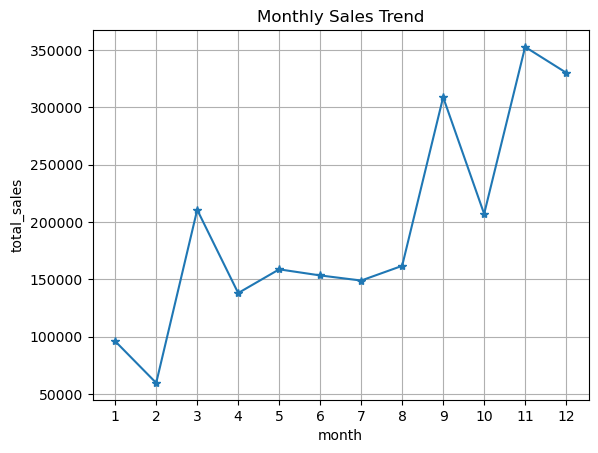

In [29]:
x=monthly_sales.index
y=monthly_sales.values
plt.plot(x,y,marker = '*')
plt.xticks(range(1,13))
plt.xlabel("month")
plt.ylabel("total_sales")
plt.title("Monthly Sales Trend")
plt.grid()

In [35]:
total_sales = df.groupby(["Category", "Sub-Category"])["Sales"].sum().reset_index()
total_sales

,Category,Sub-Category,Sales
0,Furniture,Bookcases,115361.2043
1,Furniture,Chairs,335768.2490
2,Furniture,Furnishings,95598.1260
3,Furniture,Tables,208020.1820
4,Office Supplies,Appliances,108213.1850
5,Office Supplies,Art,27659.0140
6,Office Supplies,Binders,207354.8810
7,Office Supplies,Envelopes,16528.3620
8,Office Supplies,Fasteners,8532.2400
9,Office Supplies,Labels,12695.0420


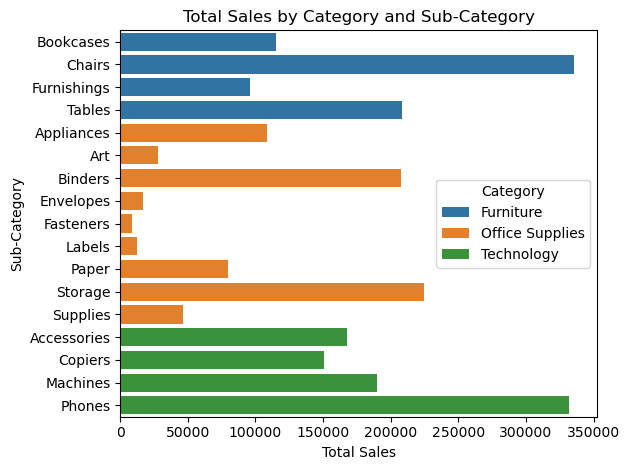

In [38]:

sns.barplot(
    data=total_sales,
    x="Sales",
    y="Sub-Category",
    hue="Category"
)

plt.title("Total Sales by Category and Sub-Category")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.legend(title="Category")
plt.tight_layout()

plt.show()

In [40]:
sales = df["Sales"]
prof = df["Profit"]

Text(0, 0.5, 'profit')

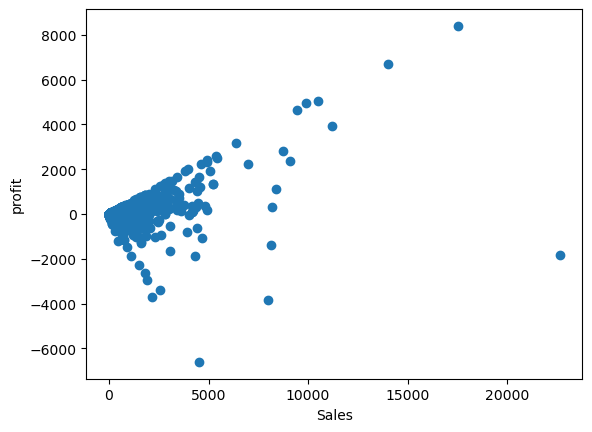

In [42]:
plt.scatter(sales , prof)
plt.xlabel("Sales")
plt.ylabel("profit")